# Bài tập thực hành tuần 9
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

In [30]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.cluster import KMeans
from sklearn.svm import SVC
sns.set_style('whitegrid')
from scipy import stats
from ipywidgets import interact, fixed
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### SVM với tập dữ liệu tách rời tuyến tính

Khởi tạo tập dữ liệu có 50 điểm và 2 cụm

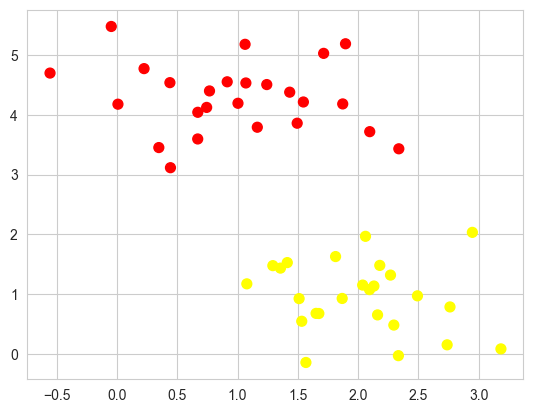

In [31]:
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

Vẽ đường thẳng phân tách 2 cụm

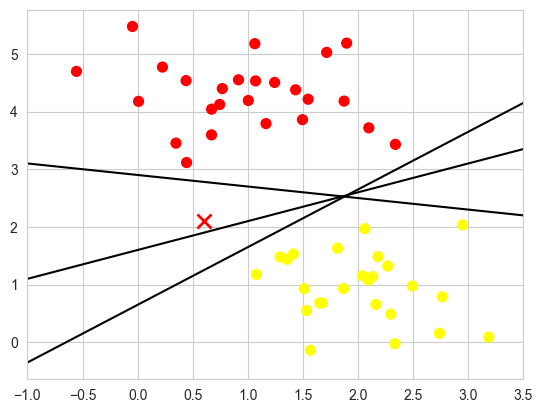

In [32]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')
    
plt.xlim(-1, 3.5)
plt.show()

Vẽ siêu phẳng lề lớn nhất

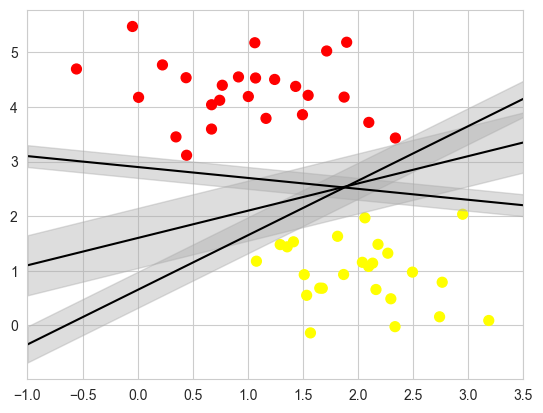

In [33]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none', color='#AAAAAA', alpha=0.4)
    
plt.xlim(-1, 3.5)
plt.show()

Sử dụng support vector classifier (SVC) của Scikit-Learn để huấn luyện mô hình
SVM và vẽ các biên quyết định của SVM

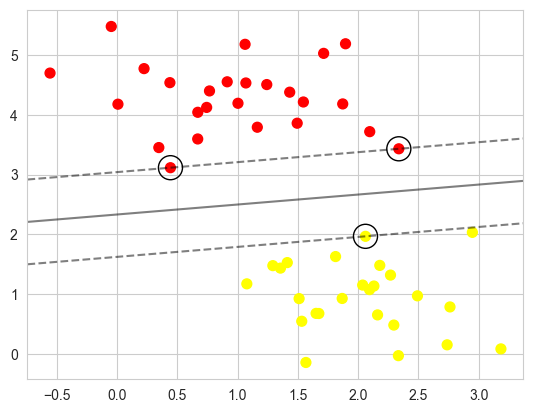

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

In [34]:
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)
plt.show()
model.support_vectors_

### SVM với tập dữ liệu không tuyến tính

Khởi tạo tập dữ liệu có 50 điểm


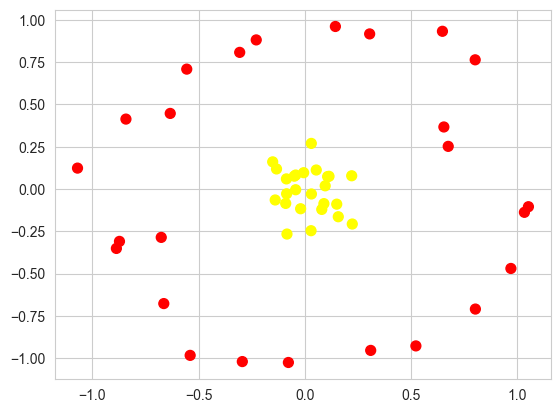

In [35]:
X, y = make_circles(50, factor = .1, noise = 0.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

Sử dụng hàm radial basis function và vẽ dữ liệu trong không gian 3 chiều

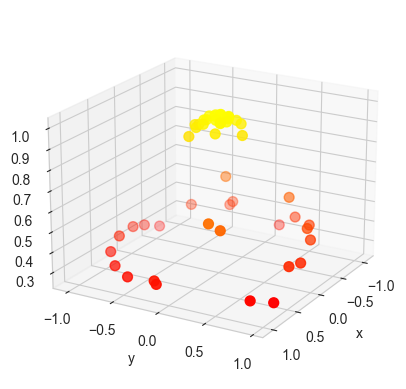

In [36]:
r = np.exp(-(X ** 2).sum(1))
ax = plt.subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=r, s=50, cmap='autumn')
ax.view_init(elev=20, azim=30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r')
plt.show()


Sử dụng support vector classifier (SVC) của Scikit-Learn để huấn luyện mô hình
SVM và vẽ các biên quyết định của SVM

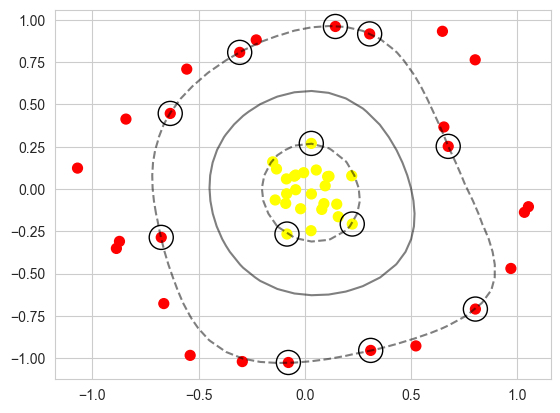

array([[ 0.67678319,  0.25202414],
       [-0.63327347,  0.44680135],
       [ 0.14502877,  0.96088463],
       [ 0.31143458, -0.9543556 ],
       [-0.30591633,  0.80778227],
       [ 0.80483712, -0.7099544 ],
       [ 0.30653296,  0.91693083],
       [-0.0764542 , -1.02578943],
       [-0.6756479 , -0.28615703],
       [-0.0831472 , -0.26640532],
       [ 0.22461252, -0.20711626],
       [ 0.0315286 ,  0.26958367]])

In [37]:
model = SVC(kernel='rbf', C=1E6)
model.fit(X, y)
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)
plt.show()
model.support_vectors_

### Áp dụng với tập dữ liệu banknote authentication từ UCI Machine Learning Repository. Kiểm tra banknote là tuyến tính hay không tuyến tính rồi áp dụng tương tự trường hợp tương ứng như trên.

In [38]:
link_hd_ko_che= r'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(link_hd_ko_che, names=columns)
df

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


Pre-processing data

In [39]:
from sklearn.preprocessing import StandardScaler
X = df.drop('class', axis=1)
y = df['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Splitting data

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=69)

In [41]:
# Mô hình Tuyến tính (Linear Margin)
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)
acc_linear = accuracy_score(y_test, svm_linear.predict(X_test))

# Mô hình Phi tuyến tính (Soft Margin - RBF Kernel)
svm_rbf = SVC(kernel='rbf', C=1E6)
svm_rbf.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test))

print(f"Độ chính xác của SVM Tuyến tính (Linear): {acc_linear * 100:.2f}%")
print(f"Độ chính xác của SVM Phi tuyến tính (RBF): {acc_rbf * 100:.2f}%")

Độ chính xác của SVM Tuyến tính (Linear): 98.79%
Độ chính xác của SVM Phi tuyến tính (RBF): 100.00%


Dựa vào kết quả ở trên, ta thấy mô hình SVM sử dụng Kernel Linear cho độ chính xác rất cao (98.79%), cho thấy dữ liệu có tính phân tách tuyến tính khá tốt. Khi sử dụng Kernel RBF thì độ chính xác đạt mức tuyệt đối (100%). Điều này chứng tỏ ranh giới giữa hai lớp (tiền thật - tiền giả) vẫn có sự lồng ghép phức tạp và mang tính phi tuyến. Do đó, việc áp dụng mô hình SVM phi tuyến là lựa chọn tốt nhất cho tập dữ liệu này.

In [42]:
X_2d = X_scaled[:, :2]

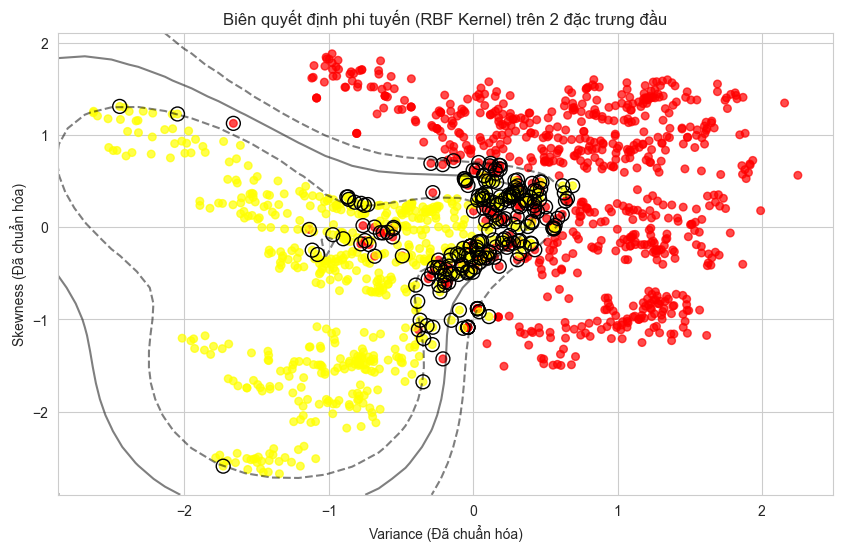

array([[-3.67717515e-02, -1.08703830e+00],
       [ 1.30137350e-01,  1.57654928e-01],
       [-3.67858274e-02, -1.08703830e+00],
       [-2.39940501e-01, -3.57994927e-01],
       [ 3.71135216e-01,  2.90621061e-01],
       [-7.21369676e-01, -1.89754674e-01],
       [ 1.86743784e-01,  6.67668084e-01],
       [ 4.22688384e-01,  2.32430268e-01],
       [ 2.21396201e-02,  6.14403225e-01],
       [-1.35326278e-01,  7.19518228e-01],
       [ 2.45612928e-01,  3.48113019e-01],
       [-5.50733967e-01, -3.17937869e-03],
       [-3.79507068e-01, -1.11277588e+00],
       [-6.83118281e-01,  7.99047211e-06],
       [ 5.79728329e-05,  6.16533819e-01],
       [ 3.01805067e-02, -8.83881863e-01],
       [ 3.24754959e-01,  3.94321350e-01],
       [ 4.81625334e-02, -3.31887476e-01],
       [-7.49169678e-01, -1.46014425e-01],
       [ 5.08903581e-01,  9.34643814e-02],
       [-1.98884472e-01, -6.30630895e-01],
       [ 4.25398005e-01,  1.86221937e-01],
       [-1.94095130e-01, -5.96780012e-01],
       [ 8.

In [43]:
# Hàm vẽ biên quyết định (tương tự như trong bài thực hành)
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Tạo lưới để đánh giá mô hình
    x = np.linspace(xlim[0], xlim[1], 30)
    y_grid = np.linspace(ylim[0], ylim[1], 30)
    Y, X_grid = np.meshgrid(y_grid, x)
    xy = np.vstack([X_grid.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X_grid.shape)
    
    # Vẽ biên quyết định và lề
    ax.contour(X_grid, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # Vẽ support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=100, linewidth=1, edgecolors='black',
                   facecolors='none')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Huấn luyện lại mô hình RBF trên dữ liệu 2D để trực quan hóa
svm_rbf_2d = SVC(kernel='rbf', C=10)
svm_rbf_2d.fit(X_2d, y)

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=30, cmap='autumn', alpha=0.7)
plot_svc_decision_function(svm_rbf_2d)
plt.title("Biên quyết định phi tuyến (RBF Kernel) trên 2 đặc trưng đầu")
plt.xlabel("Variance (Đã chuẩn hóa)")
plt.ylabel("Skewness (Đã chuẩn hóa)")
plt.show()
svm_rbf_2d.support_vectors_